## Chemins + checks

In [1]:
from pathlib import Path
import json
import numpy as np

# -----------------------
# À ADAPTER
# -----------------------
VIDEO_FILE = Path(r"C:/Users/khodj/Documents/M2_ISI/PFE/Models/ssstik.io_1769102145794.mp4")
AUDIO_PT   = Path(r"C:/Users/khodj/Documents/M2_ISI/PFE/Models/Wav2vec.pt")
VIDEO_PT   = Path(r"C:/Users/khodj/Documents/M2_ISI/PFE/Models/Resnet18.pt")

assert VIDEO_FILE.exists(), VIDEO_FILE
assert AUDIO_PT.exists(), AUDIO_PT
assert VIDEO_PT.exists(), VIDEO_PT

print("Video:", VIDEO_FILE)
print("Audio ckpt:", AUDIO_PT)
print("Video ckpt:", VIDEO_PT)


Video: C:\Users\khodj\Documents\M2_ISI\PFE\Models\ssstik.io_1769102145794.mp4
Audio ckpt: C:\Users\khodj\Documents\M2_ISI\PFE\Models\Wav2vec.pt
Video ckpt: C:\Users\khodj\Documents\M2_ISI\PFE\Models\Resnet18.pt


## Import de la “fonction app”

In [2]:
import sys

# Si late_fusion_infer.py est dans un dossier différent, ajoute-le :
# sys.path.append(r"C:\path\to\folder_that_contains_script")

from Inference_vd import late_fusion_from_video


C:\Users\khodj\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
import torch, torchvision
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
from torchvision.transforms import InterpolationMode
print("InterpolationMode OK")


torch: 2.10.0+cpu
torchvision: 0.25.0+cpu
InterpolationMode OK


## Appel “comme dans l’app”

In [4]:
import json
from pathlib import Path

import importlib, Inference_vd
importlib.reload(Inference_vd)


from Inference_vd import late_fusion_from_video


assert VIDEO_FILE.exists()
assert AUDIO_PT.exists()
assert VIDEO_PT.exists()

res = late_fusion_from_video(
    video_file=VIDEO_FILE,
    audio_pt=AUDIO_PT,
    video_pt=VIDEO_PT,
    wa=0.2,
    wv=0.8,
    num_frames=16,
    device=None
)

print(json.dumps(res, indent=2, ensure_ascii=False))



C:\Users\khodj\AppData\Roaming\Python\Python313\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


{
  "video_file": "C:\\Users\\khodj\\Documents\\M2_ISI\\PFE\\Models\\ssstik.io_1769102145794.mp4",
  "labels_9": [
    "anger",
    "calm",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
  ],
  "probs_9": [
    0.0689106285572052,
    0.0,
    0.0,
    0.07907310873270035,
    0.26786479353904724,
    0.22902975976467133,
    0.005517592653632164,
    0.32121801376342773,
    0.02838606759905815
  ],
  "pred_label": "sad",
  "weights": {
    "wa": 0.2,
    "wv": 0.8
  },
  "debug": {
    "audio_labels_8": [
      "neutral",
      "calm",
      "happy",
      "sad",
      "anger",
      "fear",
      "disgust",
      "surprise"
    ],
    "video_labels_8": [
      "neutral",
      "happy",
      "sad",
      "surprise",
      "fear",
      "anger",
      "disgust",
      "contempt"
    ],
    "num_frames": 16,
    "device": "cpu"
  }
}


## Affichage propre (top-k + prédiction)

In [5]:
labels = res["labels_9"]
probs  = np.array(res["probs_9"], dtype=float)

pred_idx = int(np.argmax(probs))
pred_lab = labels[pred_idx]
pred_p   = probs[pred_idx]

print(f"Prediction: {pred_lab} ({pred_p:.3f})")

# Top-5
topk = 5
idxs = probs.argsort()[::-1][:topk]
print("\nTop", topk)
for i in idxs:
    print(f"- {labels[i]:12s}  {probs[i]:.3f}")



Prediction: sad (0.321)

Top 5
- sad           0.321
- fear          0.268
- happy         0.229
- disgust       0.079
- anger         0.069


## Plot bar chart (lisible)

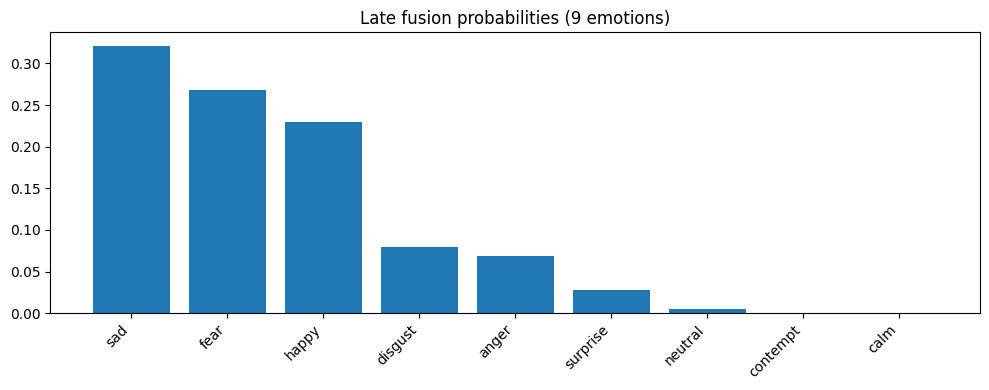

In [6]:
import matplotlib.pyplot as plt

order = probs.argsort()[::-1]
labels_sorted = [labels[i] for i in order]
probs_sorted  = probs[order]

plt.figure(figsize=(10, 4))
plt.bar(labels_sorted, probs_sorted)
plt.xticks(rotation=45, ha="right")
plt.title("Late fusion probabilities (9 emotions)")
plt.tight_layout()
plt.show()
